In [104]:
# A marketing team conducted an A/B test to evaluate whether showing a promotional advertisement (Ad) leads to a higher conversion rate compared to showing a Public Service Announcement (PSA).

# The objective of this analysis is to determine whether the observed difference in conversion rate is statistically significant and whether the advertisement should be rolled out to all users.

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
df = pd.read_csv(r"C:\Users\Raj Gupta\OneDrive\Desktop\marketing_AB.csv")

In [107]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [108]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279668,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [109]:
df.shape

(588101, 7)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [111]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [112]:
df.duplicated().sum()

0

In [113]:
df.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')

In [114]:
# The objective of exploratory data analysis is to understand the characteristics of the dataset before performing statistical testing.

# This includes analyzing the distribution of users, conversion rates, advertisement exposure, and identifying any unusual patterns.

In [115]:
df.nunique()

Unnamed: 0       588101
user id          588101
test group            2
converted             2
total ads           807
most ads day          7
most ads hour        24
dtype: int64

In [116]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

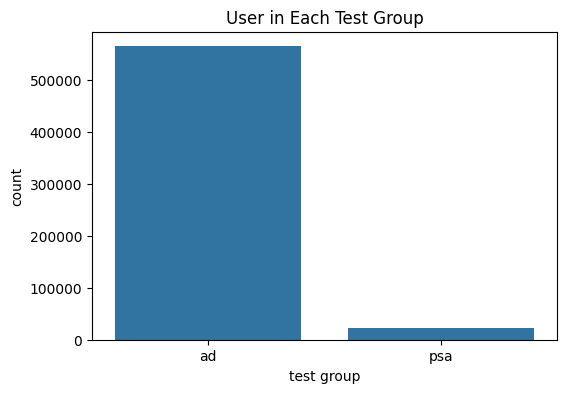

In [117]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='test group')
plt.title("User in Each Test Group")
plt.show()

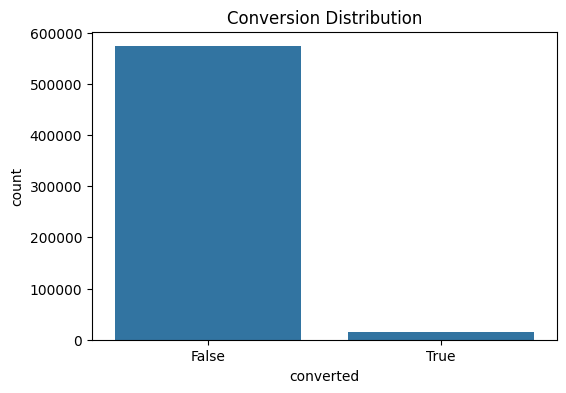

In [118]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='converted')
plt.title("Conversion Distribution")
plt.show()

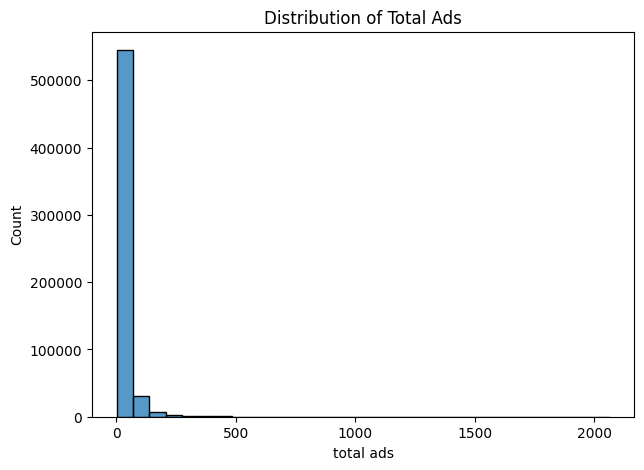

In [119]:
plt.figure(figsize=(7,5))
sns.histplot(df['total ads'], bins=30)
plt.title("Distribution of Total Ads")
plt.show()

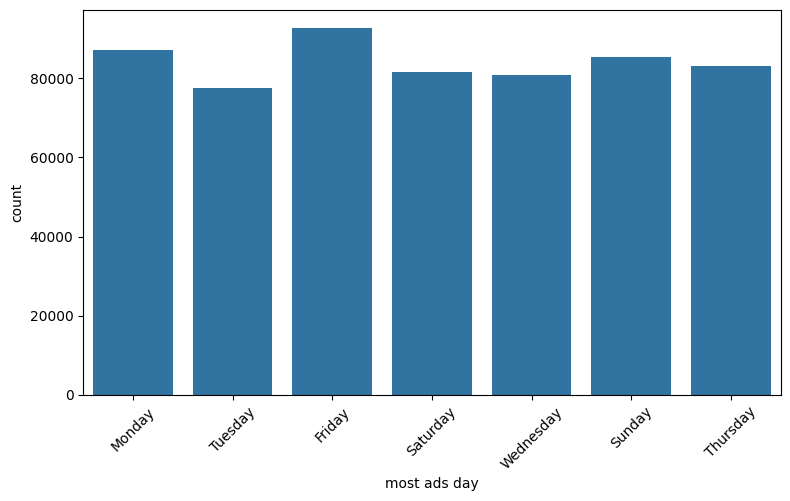

In [120]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='most ads day')
plt.xticks(rotation=45)
plt.show()

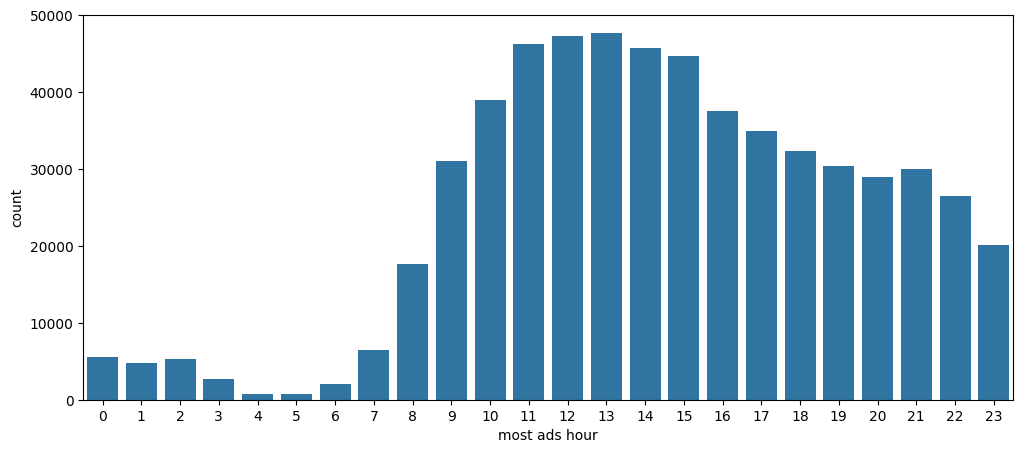

In [121]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='most ads hour')
plt.show()

In [122]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [123]:
# Conversion rate is the primary success metric for this experiment.

# It represents the percentage of users who completed the desired action after being exposed to either the advertisement or the public service announcement.

# Comparing conversion rates provides an initial indication of which experiment variant performed better.

In [124]:
conversion_rate = (
    df.groupby("test group")["converted"]
    .mean()
    .reset_index()
)

conversion_rate["converted"] = conversion_rate["converted"]*100
conversion_rate

,test group,converted
0,ad,2.554656
1,psa,1.785411


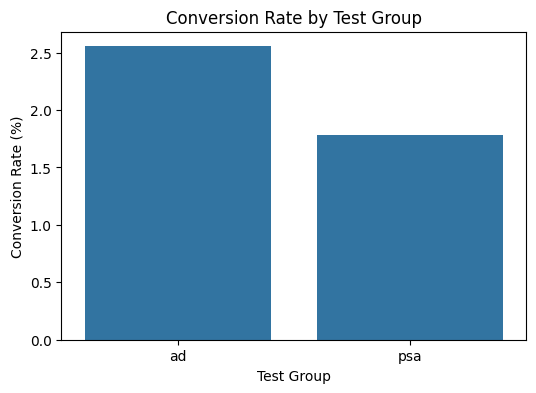

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.barplot(
    data=conversion_rate,
    x="test group",
    y="converted"
)

plt.ylabel("Conversion Rate (%)")
plt.xlabel("Test Group")
plt.title("Conversion Rate by Test Group")

plt.show()

In [126]:
summary = df.groupby("test group")["converted"].agg(
    conversions="sum",
    users='count'
)

summary["convesion_rate"] = summary["conversions"] / summary["users"]
summary

,conversions,users,convesion_rate
test group,,,
ad,14423,564577,0.025547
psa,420,23524,0.017854


In [127]:
!pip install statsmodels

In [128]:
from statsmodels.stats.proportion import proportions_ztest

success = summary["conversions"].values
nobs = summary["users"].values

z_stat, p_value = proportions_ztest(success, nobs)

print("Z Statistic:", round(z_stat,4))
print("P Value:", p_value)

Z Statistic: 7.3701
P Value: 1.7052807161559727e-13


In [129]:
## Hypothesis Testing

# H0: There is no significant difference in conversion rate between the Ad group and the PSA group.

# H1: There is a significant difference in conversion rate between the Ad group and the PSA group.

In [130]:
### Result

# - Z Statistic = 7.37
# - P Value = 1.70e-13

# Since the p-value is much smaller than the significance level (α = 0.05), we reject the null hypothesis.

# This indicates that the advertisement campaign produced a statistically significant improvement in conversion rate compared to the PSA campaign.

In [131]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci = confint_proportions_2indep(
    count1=14423,
    nobs1=564577,
    count2=420,
    nobs2=23524,
    method="wald"
)

print(ci)

(0.005950932431611005, 0.00943397395279203)


In [132]:
## Confidence Interval

# The 95% confidence interval estimates the range within which the true difference in conversion rate lies.

# If the interval does not include zero, the improvement is statistically significant.

In [133]:
summary = df.groupby("test group")["converted"].agg(
    conversions="sum",
    users="count"
)

summary["conversion_rate"] = summary["conversions"] / summary["users"]

summary

,conversions,users,conversion_rate
test group,,,
ad,14423,564577,0.025547
psa,420,23524,0.017854


In [134]:
summary.columns

Index(['conversions', 'users', 'conversion_rate'], dtype='object')

In [135]:
ad_rate = summary.loc["ad", "conversion_rate"]
psa_rate = summary.loc["psa", "conversion_rate"]

absolute_lift = ad_rate - psa_rate
relative_lift = (absolute_lift / psa_rate) * 100

print(f"Ad Conversion Rate: {ad_rate:.4%}")
print(f"PSA Conversion Rate: {psa_rate:.4%}")
print(f"Absolute Lift: {absolute_lift:.4%}")
print(f"Relative Lift: {relative_lift:.2f}%")

Ad Conversion Rate: 2.5547%
PSA Conversion Rate: 1.7854%
Absolute Lift: 0.7692%
Relative Lift: 43.09%


In [136]:
summary.rename(columns={"convesion_rate": "conversion_rate"}, inplace=True)

In [137]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    count1=14423,
    nobs1=564577,
    count2=420,
    nobs2=23524,
    method="wald"
)

print(f"95% Confidence Interval: ({ci_low:.4%}, {ci_high:.4%})")

95% Confidence Interval: (0.5951%, 0.9434%)


In [138]:
# The 95% confidence interval does not include zero, indicating that the observed improvement in conversion rate is statistically significant.

C:\Users\Raj Gupta\AppData\Local\Temp\ipykernel_68676\750989250.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


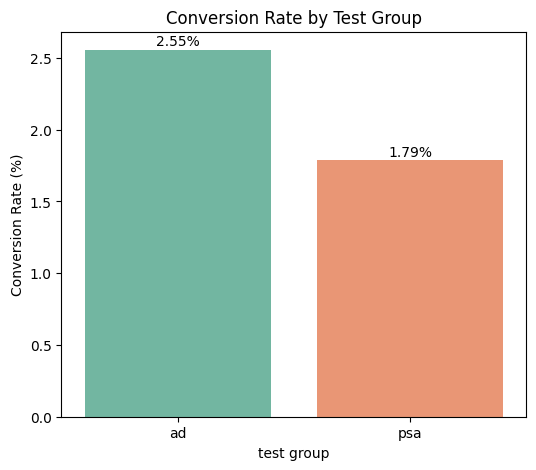

In [139]:
conversion = (
    df.groupby("test group")["converted"]
      .mean()
      .reset_index()
)

conversion["Conversion Rate (%)"] = conversion["converted"]*100

plt.figure(figsize=(6,5))

sns.barplot(
    data=conversion,
    x="test group",
    y="Conversion Rate (%)",
    palette="Set2"
)

plt.title("Conversion Rate by Test Group")
plt.ylabel("Conversion Rate (%)")

for i,v in enumerate(conversion["Conversion Rate (%)"]):
    plt.text(i,v+0.03,f"{v:.2f}%",ha="center")

plt.show()

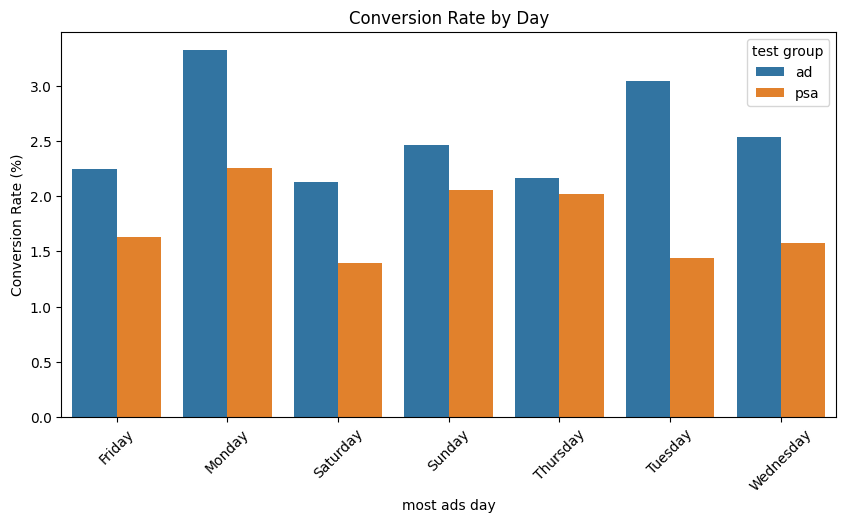

In [140]:
day = (
    df.groupby(["most ads day","test group"])["converted"]
      .mean()
      .reset_index()
)

day["converted"]*=100

plt.figure(figsize=(10,5))

sns.barplot(
    data=day,
    x="most ads day",
    y="converted",
    hue="test group"
)

plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Day")
plt.xticks(rotation=45)

plt.show()

In [141]:
# This analysis identifies whether campaign performance varies across weekdays and whether the advertisement consistently outperforms the PSA.

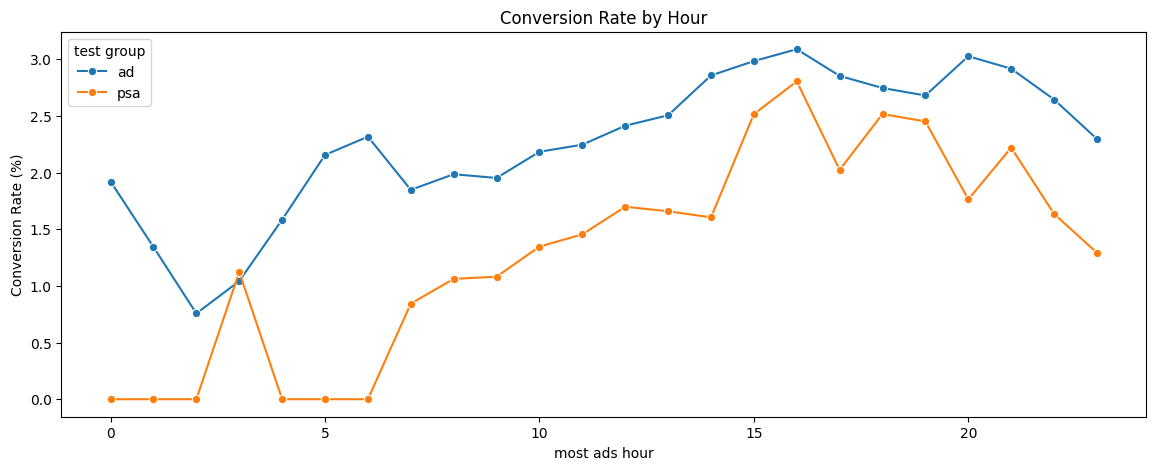

In [142]:
hour = (
    df.groupby(["most ads hour","test group"])["converted"]
      .mean()
      .reset_index()
)

hour["converted"]*=100

plt.figure(figsize=(14,5))

sns.lineplot(
    data=hour,
    x="most ads hour",
    y="converted",
    hue="test group",
    marker="o"
)

plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Hour")

plt.show()

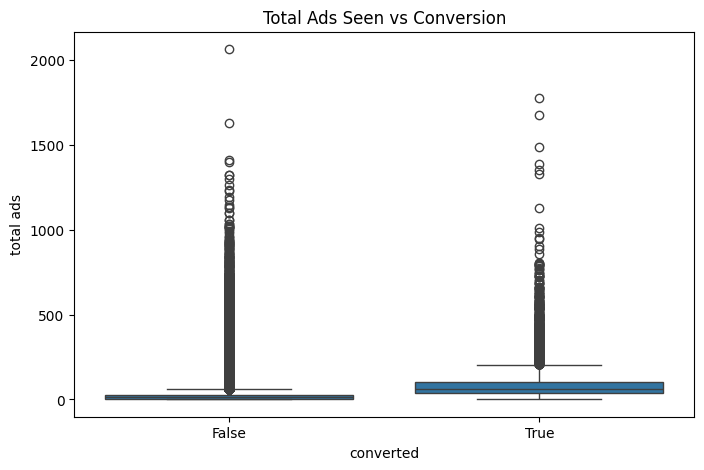

In [143]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="converted",
    y="total ads"
)

plt.title("Total Ads Seen vs Conversion")

plt.show()

In [144]:
df.groupby("converted")["total ads"].mean()

converted
False    23.291495
True     83.887759
Name: total ads, dtype: float64

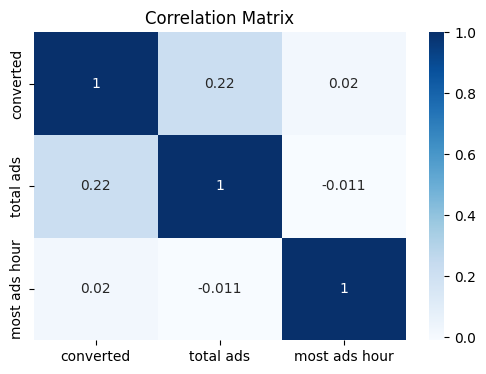

In [145]:
corr = df[["converted","total ads","most ads hour"]].corr(numeric_only=True)

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

In [146]:
print("="*40)
print("A/B TEST SUMMARY")
print("="*40)

print(f"Total Users : {len(df):,}")

print(f"Ad Users : {summary.loc['ad','users']:,}")
print(f"PSA Users : {summary.loc['psa','users']:,}")

print(f"Ad Conversion Rate : {ad_rate:.2%}")
print(f"PSA Conversion Rate : {psa_rate:.2%}")

print(f"Absolute Lift : {absolute_lift:.2%}")
print(f"Relative Lift : {relative_lift:.2f}%")

print(f"Z Statistic : {z_stat:.4f}")
print(f"P Value : {p_value:.10f}")

A/B TEST SUMMARY
Total Users : 588,101
Ad Users : 564,577
PSA Users : 23,524
Ad Conversion Rate : 2.55%
PSA Conversion Rate : 1.79%
Absolute Lift : 0.77%
Relative Lift : 43.09%
Z Statistic : 7.3701
P Value : 0.0000000000


In [147]:
# Business Recommendation

## Key Findings

# The advertisement group achieved a conversion rate of **2.55%** compared to **1.79%** for the PSA group.
# The campaign generated an approximate **43% relative lift** in conversion.
# The Two-Proportion Z-Test produced a p-value much smaller than 0.05, indicating that the observed improvement is statistically significant.

## Recommendation

# Based on the experimental results, we recommend deploying the advertisement campaign to a larger audience. Future experiments should evaluate long-term customer retention, revenue impact, and campaign performance across different customer segments.